<a href="https://colab.research.google.com/github/chetan003-lab/Data-Science-Internship-Task-4/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [80]:
# Load Titanic dataset

df = pd.read_csv("/content/Titanic-Dataset[1].csv")

# Display first rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [81]:
df.shape

(891, 12)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [83]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [84]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [85]:
df['Age'].fillna(
    df['Age'].mean(),
    inplace=True
)

In [86]:
df['Embarked'].fillna(
    df['Embarked'].mode()[0],
    inplace=True
)

In [87]:
df.drop(
    'Cabin',
    axis=1,
    inplace=True
)

In [88]:
df['Family_Size'] = (
    df['SibSp'] + df['Parch'] + 1
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


In [89]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,12,18,35,60,100],
    labels=[
        'Child',
        'Teen',
        'Adult',
        'Middle Age',
        'Senior'
    ]
)

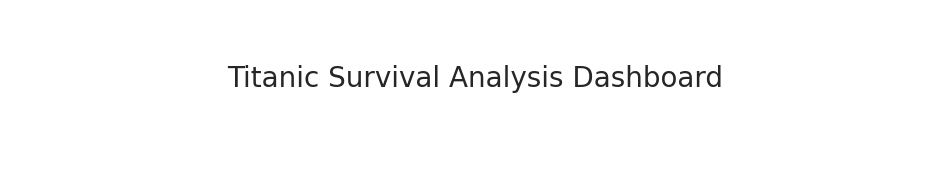

In [90]:
plt.figure(figsize=(12,2))

plt.text(
    0.5,
    0.5,
    "Titanic Survival Analysis Dashboard",
    fontsize=20,
    ha='center'
)

plt.axis('off')

plt.show()

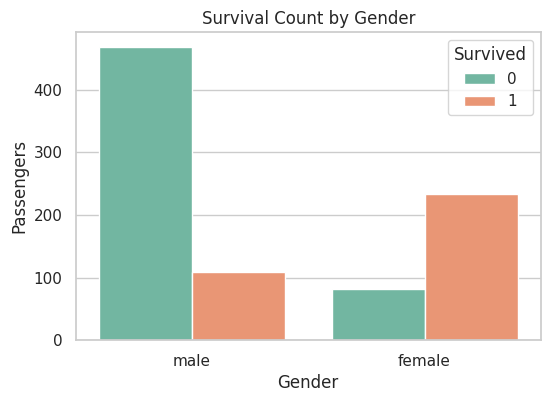

In [91]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Passengers")

plt.show()

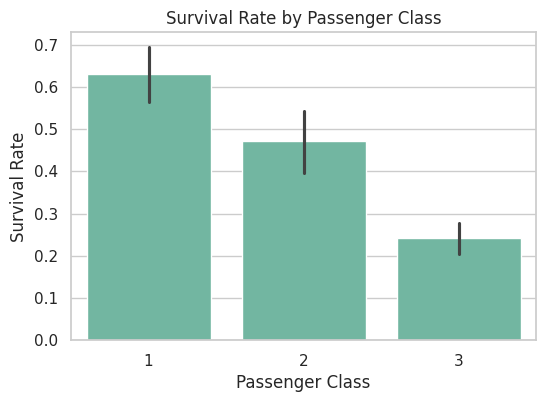

In [92]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Pclass',
    y='Survived',
    data=df
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

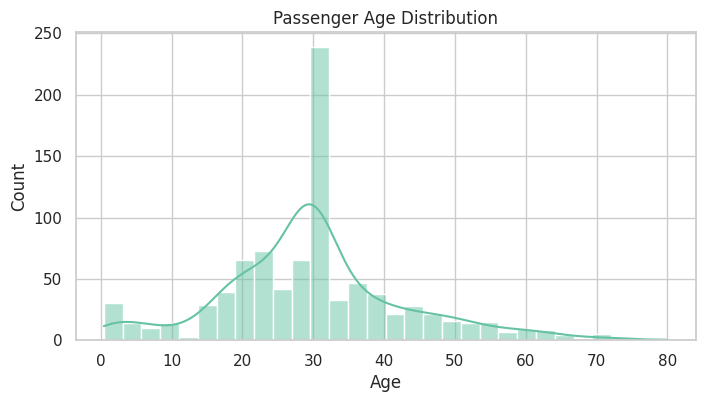

In [95]:
plt.figure(figsize=(8,4))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

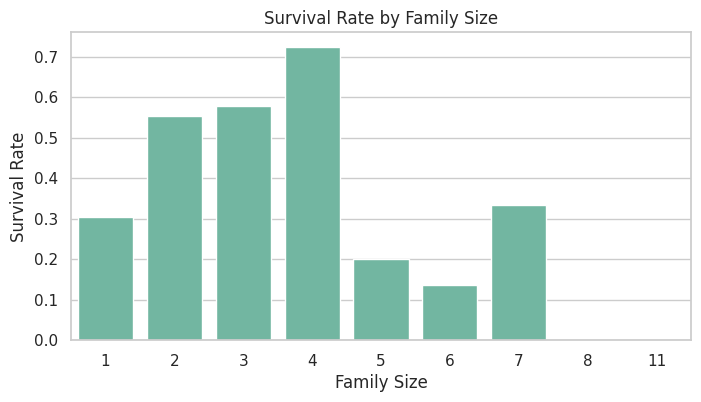

In [96]:
  plt.figure(figsize=(8,4))

family_survival = df.groupby(
    'Family_Size'
)['Survived'].mean()


sns.barplot(
    x=family_survival.index,
    y=family_survival.values
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()

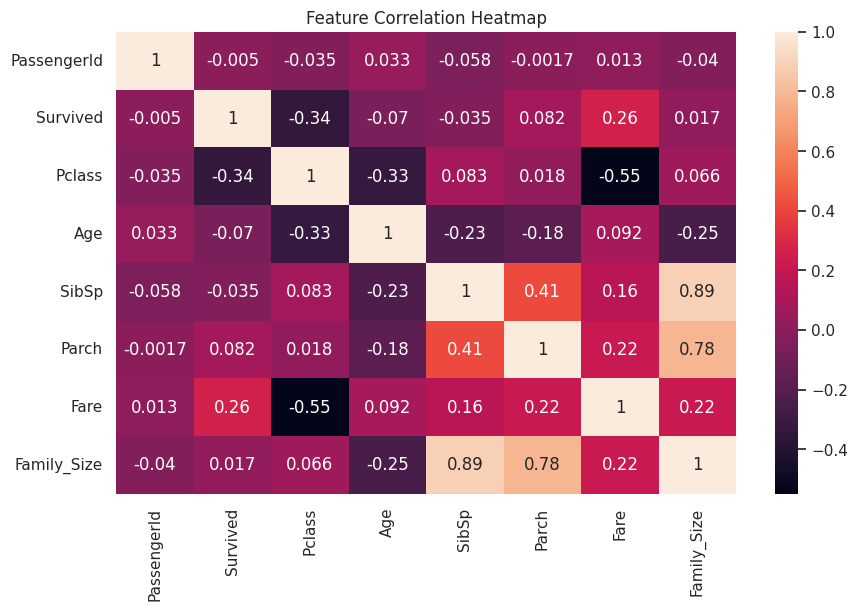

In [97]:
plt.figure(figsize=(10,6))


numeric_data = df.select_dtypes(
    include=['int64','float64']
)


sns.heatmap(
    numeric_data.corr(),
    annot=True
)


plt.title("Feature Correlation Heatmap")

plt.show()

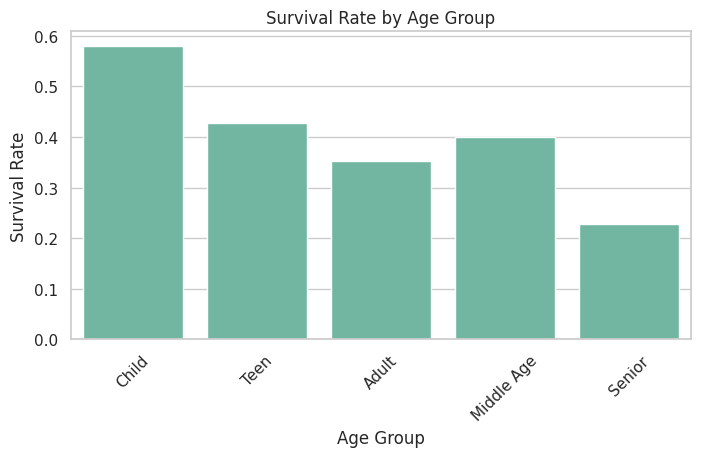

In [98]:
plt.figure(figsize=(8,4))

age_survival = df.groupby(
    'Age_Group'
)['Survived'].mean()


sns.barplot(
    x=age_survival.index,
    y=age_survival.values
)


plt.title("Survival Rate by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Survival Rate")

plt.xticks(rotation=45)

plt.show()

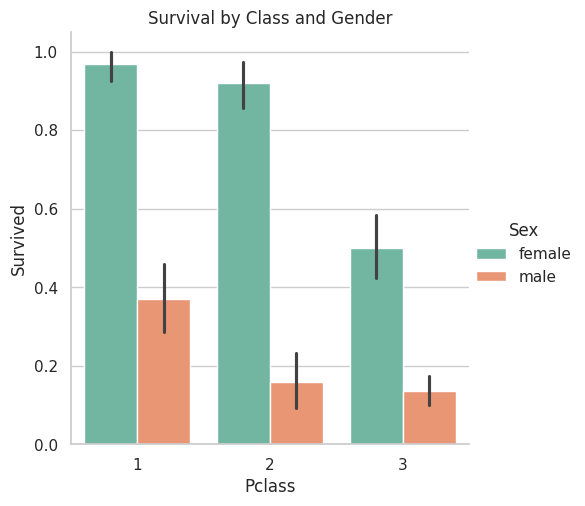

In [99]:
sns.catplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex",
    kind="bar",
    height=5
)

plt.title(
    "Survival by Class and Gender"
)

plt.show()

In [100]:
print("Total Passengers:", len(df))

print(
    "\nOverall Survival Rate:",
    df['Survived'].mean()
)

print(
    "\nSurvival by Gender:"
)

print(
    df.groupby('Sex')['Survived'].mean()
)

print(
    "\nSurvival by Class:"
)

print(
    df.groupby('Pclass')['Survived'].mean()
)

Total Passengers: 891

Overall Survival Rate: 0.3838383838383838

Survival by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival by Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
